In [1]:

import logging
import math
import sys
import random
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import tsplib95

from pymoo.indicators.hv import HV
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting


logging.basicConfig(level=logging.INFO)


# Carregamento da instância TSP -> matriz de distâncias
graph = tsplib95.load('data/att48.tsp')
n = graph.dimension

dist_mtx = np.zeros((n, n), dtype=np.float64)

for i in range(n):
    for j in range(n):
        if i == j:
            dist_mtx[i, j] = math.inf
        else:
            dist_mtx[i, j] = graph.get_weight(i + 1, j + 1)


coords = np.array(
    [graph.node_coords[i + 1] for i in range(n)], dtype=np.float64
)

# Importante colocar diagonal como infinito (se não vai dar pau no DP)

In [2]:
import sys
from pathlib import Path

# Ajuste do path do projeto
project_root = Path.cwd().parents[1] 
src_path = project_root / "src"

sys.path.insert(0, str(src_path))

print(src_path)

c:\Telecom Files\comp_ev_group_F\src


In [3]:
from TP.problems.vrp.utils.problem_data import VRPProblemData
from TP.core.logging.observer import BestFitnessLogger
from TP.core.logging.progress import EALogger
from TP.core.multiobjective.selection.parents.operators import CrowdTournament
from TP.core.multiobjective.selection.survivors.operators import (
    NonDominanceOrdering,
)
from TP.core.variation.mutation import RSM
from TP.problems.tsp.variation.recombination import SCX
from TP.problems.vrp.NSGAII_interface import VRPNSGAIIOrchestrator

problem_instance = VRPProblemData(
    n_vehicles=5, depot_node=0, dist_mtx=dist_mtx
)

In [4]:
# Parâmetros do experimento
N_RUNS = 30
BASE_SEED = 42

pop_size = 140
tournament_size = 7
max_generations = 600

p_c = 0.8
p_m = 0.25
p_ls = 0.15

# Critério de convergência via HV history 
# o HV melhora menos do que "hv_tol_rel" relativamente ao melhor HV já observado.
hv_tol_rel = 5e-2
hv_patience = 30
min_generations_for_convergence = 50
STORE_ALL_GENERATION_FRONTS = True

In [5]:
# ============================================================
# Funções auxiliares

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)


def fitness_obj_to_array(front):
    """
    Converte uma fronteira do data_logger.best_fitness
    (objetos de fitness) para ndarray shape (n_points, 2)
    """
    if front is None or len(front) == 0:
        return np.empty((0, 2), dtype=float)

    return np.array([
        [f.total_distance.value, f.max_imbalance.value]
        for f in front
    ], dtype=float)


def indiv_front_to_array(front):
    """
    Converte uma fronteira contendo indivíduos (ex.: out.fronts[i])
    para ndarray shape (n_points, 2)
    """
    if front is None or len(front) == 0:
        return np.empty((0, 2), dtype=float)

    return np.array([
        [ind.fitness.total_distance.value, ind.fitness.max_imbalance.value]
        for ind in front
    ], dtype=float)


def get_non_dominated_front(points: np.ndarray) -> np.ndarray:
    """
    Retorna apenas os pontos não dominados.
    """
    if points is None or len(points) == 0:
        return np.empty((0, 2), dtype=float)

    nds = NonDominatedSorting()
    idx = nds.do(points, only_non_dominated_front=True)
    F_nd = points[idx]

    # Ordena pelo primeiro objetivo para visualização
    order = np.argsort(F_nd[:, 0])
    return F_nd[order]


def normalize_with_reference(A: np.ndarray, F_ref: np.ndarray):
    """
    Normaliza A usando min/max extraídos da fronteira de referência F_ref.
    """
    mins = F_ref.min(axis=0)
    maxs = F_ref.max(axis=0)
    ranges = np.where(maxs - mins == 0, 1.0, maxs - mins)
    A_norm = (A - mins) / ranges
    F_ref_norm = (F_ref - mins) / ranges
    return A_norm, F_ref_norm, mins, maxs


def compute_hv_history(fronts_history, ref_point):
    """
    Calcula HV para cada fronteira em fronts_history com um reference point fixo.
    """
    hv = HV(ref_point=ref_point)
    hv_hist = []

    for F in fronts_history:
        if F is None or len(F) == 0:
            hv_hist.append(np.nan)
        else:
            hv_hist.append(hv(F))

    return np.array(hv_hist, dtype=float)


def detect_convergence_generation_from_hv(
    hv_history,
    min_rel_gain=1e-2,   # 1% na janela
    patience=30,
    min_generations=50
):
    """
    Detecta convergência por baixo ganho percentual acumulado do HV
    ao longo de uma janela de 'patience' gerações.
    """
    hv = np.asarray(hv_history, dtype=float)

    valid_idx = np.where(~np.isnan(hv))[0]
    if len(valid_idx) == 0:
        return len(hv) - 1
    hv_filled = hv.copy()
    first_valid = valid_idx[0]
    for i in range(first_valid + 1, len(hv_filled)):
        if np.isnan(hv_filled[i]):
            hv_filled[i] = hv_filled[i - 1]

    # Usa o melhor HV acumulado para reduzir sensibilidade a oscilações
    hv_best = hv_filled.copy()
    hv_best[first_valid:] = np.maximum.accumulate(hv_filled[first_valid:])

    # Não dá para avaliar antes de ter a janela completa
    start_g = max(first_valid + patience - 1, min_generations - 1)

    for g in range(start_g, len(hv_best)):
        window_start = g - patience + 1

        hv_start = hv_best[window_start]
        hv_end = hv_best[g]

        rel_gain = (hv_end - hv_start) / max(abs(hv_start), 1e-12)

        if rel_gain < min_rel_gain:
            return window_start

    return len(hv_best) - 1



def summarize_metric(values):
    values = np.asarray(values, dtype=float)
    return {
        "mean": np.nanmean(values),
        "std": np.nanstd(values, ddof=1) if np.sum(~np.isnan(values)) > 1 else np.nan,
        "median": np.nanmedian(values),
        "min": np.nanmin(values),
        "max": np.nanmax(values),
    }


def plot_hv_histories(results, n_show=10):
    """
    Plota HV histories das primeiras n_show execuções.
    """
    fig = go.Figure()

    for i, res in enumerate(results[:n_show]):
        fig.add_trace(
            go.Scatter(
                x=np.arange(1, len(res["hv_history"]) + 1),
                y=res["hv_history"],
                mode="lines",
                name=f'Run {res["run_id"]}'
            )
        )

    fig.update_layout(
        title=f'HV history (primeiras {min(n_show, len(results))} execuções)',
        xaxis_title='Geração',
        yaxis_title='Hypervolume',
        legend_title='Execução'
    )
    fig.show()


def plot_reference_vs_run(F_ref, F_run, run_id=None):
    plt.figure(figsize=(8, 6))
    plt.scatter(F_ref[:, 0], F_ref[:, 1], s=70, label="Fronteira de referência")
    plt.scatter(F_run[:, 0], F_run[:, 1], s=35, label=f"Run {run_id}" if run_id is not None else "Run")
    plt.xlabel("Distância Total")
    plt.ylabel("Desbalanceamento")
    plt.grid(True)
    plt.legend()
    plt.show()

In [6]:
# Execução de uma run

def run_single_experiment(run_id: int, seed: int):
    set_seed(seed)

    data_logger = BestFitnessLogger()

    # Imprime apenas de 100 em 100
    process_logger = EALogger()

    parent_selector = CrowdTournament(tournament_size=tournament_size)
    survivor_selector = NonDominanceOrdering()
    recombinator = SCX(dist_mtx=problem_instance.dist_mtx)
    mutation_operator = RSM()

    orchestrator = VRPNSGAIIOrchestrator(
        problem_instance=problem_instance,
        survivor_selector=survivor_selector,
        mutation_operator=mutation_operator,
        recombinator=recombinator,
        pop_size=pop_size,
        parent_selector=parent_selector,
        max_generations=max_generations,
        observers=[data_logger],
        loggers=[process_logger],
        p_c=p_c,
        p_m=p_m,
        p_ls=p_ls,
    )

    t0 = perf_counter()
    out = orchestrator.run()
    t_total = perf_counter() - t0

    # Histórico das fronteiras de primeira frente por geração
    fronts_history = [fitness_obj_to_array(front) for front in data_logger.best_fitness]

    # Gerações realmente registradas
    generations_logged = list(data_logger.generations)

    # Fronteira final
    F_final = fronts_history[-1] if len(fronts_history) > 0 else np.empty((0, 2), dtype=float)

    n_generations_executed = max_generations

    result = {
        "run_id": run_id,
        "seed": seed,
        "out": out,
        "generations_logged": generations_logged,
        "fronts_history": fronts_history if STORE_ALL_GENERATION_FRONTS else None,
        "final_front": F_final,
        "total_cpu_time": t_total,
        "n_generations_executed": n_generations_executed,
    }

    return result

In [8]:
# Rodar 30 execuções independentes
results = []

for run_id in range(1, N_RUNS + 1):
    seed = BASE_SEED + run_id
    print(f"=== Run {run_id}/{N_RUNS} | seed={seed} ===")
    
    res = run_single_experiment(run_id=run_id, seed=seed)
    results.append(res)

    # Diagnóstico da primeira run
    if run_id == 1:
        print("Primeiras gerações logadas:", res["generations_logged"][:10])
        print("Últimas gerações logadas:", res["generations_logged"][-10:])
        print("Qtd. de pontos logados:", len(res["generations_logged"]))
        print("n_generations_executed:", res["n_generations_executed"])

print("Execuções finalizadas.")


=== Run 1/30 | seed=43 ===


INFO:TP.core.logging.progress:EA started | population_size=140
INFO:TP.core.logging.progress:Generation 100 | Best front size=9 | Pop Size=140
INFO:TP.core.logging.progress:Generation 200 | Best front size=10 | Pop Size=140
INFO:TP.core.logging.progress:Generation 300 | Best front size=11 | Pop Size=140
INFO:TP.core.logging.progress:Generation 400 | Best front size=16 | Pop Size=140
INFO:TP.core.logging.progress:Generation 500 | Best front size=6 | Pop Size=140
INFO:TP.core.logging.progress:Generation 600 | Best front size=8 | Pop Size=140
INFO:TP.core.logging.progress:EA finished | generations=601 | best front size=9.00000 | feasible=False


Primeiras gerações logadas: [100, 200, 300, 400, 500, 600]
Últimas gerações logadas: [100, 200, 300, 400, 500, 600]
Qtd. de pontos logados: 6
n_generations_executed: 600
=== Run 2/30 | seed=44 ===


INFO:TP.core.logging.progress:EA started | population_size=140
INFO:TP.core.logging.progress:Generation 100 | Best front size=6 | Pop Size=140
INFO:TP.core.logging.progress:Generation 200 | Best front size=8 | Pop Size=140
INFO:TP.core.logging.progress:Generation 300 | Best front size=9 | Pop Size=140
INFO:TP.core.logging.progress:Generation 400 | Best front size=10 | Pop Size=140
INFO:TP.core.logging.progress:Generation 500 | Best front size=8 | Pop Size=140
INFO:TP.core.logging.progress:Generation 600 | Best front size=10 | Pop Size=140
INFO:TP.core.logging.progress:EA finished | generations=601 | best front size=8.00000 | feasible=False


=== Run 3/30 | seed=45 ===


...

=== Run 29/30 | seed=71 ===


INFO:TP.core.logging.progress:EA started | population_size=140
INFO:TP.core.logging.progress:Generation 100 | Best front size=9 | Pop Size=140
INFO:TP.core.logging.progress:Generation 200 | Best front size=6 | Pop Size=140
INFO:TP.core.logging.progress:Generation 300 | Best front size=8 | Pop Size=140
INFO:TP.core.logging.progress:Generation 400 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:Generation 500 | Best front size=10 | Pop Size=140
INFO:TP.core.logging.progress:Generation 600 | Best front size=10 | Pop Size=140
INFO:TP.core.logging.progress:EA finished | generations=601 | best front size=10.00000 | feasible=False


=== Run 30/30 | seed=72 ===


INFO:TP.core.logging.progress:EA started | population_size=140
INFO:TP.core.logging.progress:Generation 100 | Best front size=12 | Pop Size=140
INFO:TP.core.logging.progress:Generation 200 | Best front size=9 | Pop Size=140
INFO:TP.core.logging.progress:Generation 300 | Best front size=7 | Pop Size=140
INFO:TP.core.logging.progress:Generation 400 | Best front size=6 | Pop Size=140
INFO:TP.core.logging.progress:Generation 500 | Best front size=20 | Pop Size=140
INFO:TP.core.logging.progress:Generation 600 | Best front size=8 | Pop Size=140
INFO:TP.core.logging.progress:EA finished | generations=601 | best front size=6.00000 | feasible=False


Execuções finalizadas.


Total de pontos vindos das fronteiras finais: 264
Tamanho da fronteira global de referência: 21
Reference point global: [58995.2 13653.2]


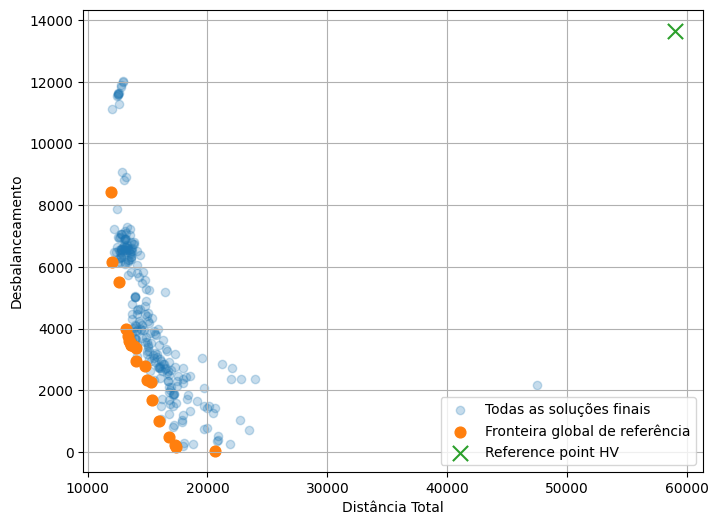

In [9]:
# Fronteira global de referência e ref_point global do HV

# União das fronteiras finais das 30 execuções
all_final_points = np.vstack([res["final_front"] for res in results if res["final_front"] is not None and len(res["final_front"]) > 0])

print("Total de pontos vindos das fronteiras finais:", len(all_final_points))

# Fronteira global de referência = não dominadas da união
F_ref_global = get_non_dominated_front(all_final_points)

print("Tamanho da fronteira global de referência:", len(F_ref_global))

# Ponto de referência global (fixo para comparabilidade do HV)
# pior do que todos os pontos observados
all_points_for_hv = []

for res in results:
    if res["fronts_history"] is not None:
        for F in res["fronts_history"]:
            if F is not None and len(F) > 0:
                all_points_for_hv.append(F)

all_points_for_hv = np.vstack(all_points_for_hv)
ref_point_global = all_points_for_hv.max(axis=0) * 1.10

print("Reference point global:", ref_point_global)

# Visualização
plt.figure(figsize=(8, 6))
plt.scatter(all_final_points[:, 0], all_final_points[:, 1], alpha=0.25, label="Todas as soluções finais")
plt.scatter(F_ref_global[:, 0], F_ref_global[:, 1], s=60, label="Fronteira global de referência")
plt.scatter(ref_point_global[0], ref_point_global[1], marker="x", s=120, label="Reference point HV")
plt.xlabel("Distância Total")
plt.ylabel("Desbalanceamento")
plt.grid(True)
plt.legend()
plt.show()

In [10]:
# HV history + convergência por run

for res in results:
    hv_history = compute_hv_history(
        fronts_history=res["fronts_history"],
        ref_point=ref_point_global
    )

    generations_logged = res["generations_logged"]
    n_exec = res["n_generations_executed"]

    conv_gen_idx = detect_convergence_generation_from_hv(
        hv_history,
        min_rel_gain=hv_tol_rel,
        patience=hv_patience,
        min_generations=min_generations_for_convergence
    )

    # Se convergiu, pega a geração REAL correspondente ao índice do HV
    if conv_gen_idx is not None and conv_gen_idx < len(generations_logged):
        conv_generation = generations_logged[conv_gen_idx]

        # Se seu logger começa em 0, o tempo proporcional usa conv_generation + 1
        conv_time = res["total_cpu_time"] * ((conv_generation + 1) / n_exec)
    else:
        # Não convergiu até o fim -> convergência = execução total
        conv_generation = n_exec
        conv_time = res["total_cpu_time"]

    res["hv_history"] = hv_history
    res["hv_final"] = hv_history[-1] if len(hv_history) > 0 else np.nan
    res["convergence_generation_idx"] = conv_gen_idx
    res["convergence_generation"] = conv_generation
    res["convergence_cpu_time"] = conv_time

print("HV history e convergência calculados.")

HV history e convergência calculados.


In [11]:
# GD / IGD por execução
for res in results:
    F_run = res["final_front"]

    if F_run is None or len(F_run) == 0:
        res["gd"] = np.nan
        res["igd"] = np.nan
        res["gd_norm"] = np.nan
        res["igd_norm"] = np.nan
        continue

    # Versões originais
    res["gd"] = GD(F_ref_global)(F_run)
    res["igd"] = IGD(F_ref_global)(F_run)

    # Versões normalizadas
    F_run_norm, F_ref_norm, mins, maxs = normalize_with_reference(F_run, F_ref_global)
    res["gd_norm"] = GD(F_ref_norm)(F_run_norm)
    res["igd_norm"] = IGD(F_ref_norm)(F_run_norm)

print("GD / IGD calculados para todas as execuções.")

GD / IGD calculados para todas as execuções.


In [12]:
# DataFrame consolidado por execução

df_runs = pd.DataFrame([
    {
        "run_id": res["run_id"],
        "seed": res["seed"],
        "n_generations_executed": res["n_generations_executed"],
        "total_cpu_time": res["total_cpu_time"],
        "convergence_generation": res["convergence_generation"],
        "convergence_cpu_time": res["convergence_cpu_time"],
        "hv_final": res["hv_final"],
        "gd": res["gd"],
        "igd": res["igd"],
        "gd_norm": res["gd_norm"],
        "igd_norm": res["igd_norm"],
        "final_front_size": len(res["final_front"]) if res["final_front"] is not None else 0,
    }
    for res in results
])

df_runs

,run_id,seed,n_generations_executed,total_cpu_time,convergence_generation,convergence_cpu_time,hv_final,gd,igd,gd_norm,igd_norm,final_front_size
0,1,43,600,772.551603,600,773.839189,6.075393e+08,578.154318,949.349846,0.068114,0.112527,8
1,2,44,600,536.855751,600,537.750511,5.913591e+08,1380.844489,1651.518324,0.163381,0.194107,10
2,3,45,600,424.128130,600,424.835010,6.051755e+08,1042.895955,1354.319144,0.122414,0.158221,8
3,4,46,600,353.677621,600,354.267083,5.646080e+08,1217.467896,1232.591592,0.142972,0.144712,7
4,5,47,600,340.925525,600,341.493734,5.058924e+08,1798.504567,1783.753144,0.212724,0.210995,8
5,6,48,600,332.885481,600,333.440290,5.874448e+08,1725.424083,1587.883972,0.202723,0.186724,11
6,7,49,600,346.877851,600,347.455981,6.087748e+08,517.328086,678.507417,0.060939,0.079750,13
7,8,50,600,347.970390,600,348.550340,6.003991e+08,923.605521,1257.927029,0.108749,0.146592,6
8,9,51,600,357.488016,600,358.083829,5.036966e+08,2020.636057,1683.603725,0.238122,0.199033,6
9,10,52,600,348.003406,600,348.583411,5.090277e+08,2898.964325,1516.431081,0.337970,0.178338,18


In [13]:
# Estatísticas resumo (média, std, etc.)

metrics_summary = pd.DataFrame({
    "total_cpu_time": summarize_metric(df_runs["total_cpu_time"]),
    "convergence_generation": summarize_metric(df_runs["convergence_generation"]),
    "convergence_cpu_time": summarize_metric(df_runs["convergence_cpu_time"]),
    "hv_final": summarize_metric(df_runs["hv_final"]),
    "gd": summarize_metric(df_runs["gd"]),
    "igd": summarize_metric(df_runs["igd"]),
    "gd_norm": summarize_metric(df_runs["gd_norm"]),
    "igd_norm": summarize_metric(df_runs["igd_norm"]),
    "final_front_size": summarize_metric(df_runs["final_front_size"]),
}).T

metrics_summary

,mean,std,median,min,max
total_cpu_time,3.802743e+02,8.719247e+01,3.474410e+02,3.326473e+02,7.725516e+02
convergence_generation,6.000000e+02,0.000000e+00,6.000000e+02,6.000000e+02,6.000000e+02
convergence_cpu_time,3.809081e+02,8.733779e+01,3.480201e+02,3.332018e+02,7.738392e+02
hv_final,5.620494e+08,3.448696e+07,5.690229e+08,4.953758e+08,6.087748e+08
gd,1.265331e+03,5.347300e+02,1.260736e+03,3.236940e+02,2.898964e+03
igd,1.260059e+03,3.460471e+02,1.349946e+03,6.186159e+02,1.783753e+03
gd_norm,1.488918e-01,6.269257e-02,1.482782e-01,3.827133e-02,3.379695e-01
igd_norm,1.482345e-01,4.063287e-02,1.579878e-01,7.269723e-02,2.109946e-01
final_front_size,8.800000e+00,2.708862e+00,8.000000e+00,6.000000e+00,1.800000e+01


In [14]:
# Salvar resultados

import pickle

output_dir = Path("results_biobj_vrp")
output_dir.mkdir(exist_ok=True)

df_runs.to_csv(output_dir / "runs_metrics.csv", index=False)
metrics_summary.to_csv(output_dir / "summary_metrics.csv")

artifacts = {
    "results": results,
    "F_ref_global": F_ref_global,
    "ref_point_global": ref_point_global,
    "df_runs": df_runs,
    "metrics_summary": metrics_summary,
    "config": {
        "N_RUNS": N_RUNS,
        "BASE_SEED": BASE_SEED,
        "pop_size": pop_size,
        "tournament_size": tournament_size,
        "max_generations": max_generations,
        "p_c": p_c,
        "p_m": p_m,
        "p_ls": p_ls,
        "hv_tol_rel": hv_tol_rel,
        "hv_patience": hv_patience,
        "min_generations_for_convergence": min_generations_for_convergence,
    }
}

with open(output_dir / "artifacts.pkl", "wb") as f:
    pickle.dump(artifacts, f)

print("Arquivos salvos em:", output_dir.resolve())

Arquivos salvos em: C:\Telecom Files\comp_ev_group_F\notebooks\TF\results_biobj_vrp
